# Foci density as a proxy for uneven barcode density

Follow-up to `test_weighted_average_intensity.ipynb`: that notebook's WAI
(mean raw-frame intensity, averaged over the 16 combinatorial barcode bits)
turned out to be confounded on these high-background datasets -- a low WAI
value can mean either "few real barcode spots" or "high background with a
normal spot count", and the two aren't distinguishable from a mean alone.

**Metric used here instead**: for each FOV, at one fixed z-plane, detect
individual fluorescent foci in each of the 16 barcode bits' own raw frames
(background-subtraction + local-maxima detection, reusing
`MERci.analysis.fast_spot_quantification.detect_foci_in_crop` --
the same primitive `during_imaging/fast_spot_quantification.ipynb` already
uses for per-bit reagent QC), then pool across all 16 bits into two per-FOV
scalars: `n_foci` (count) and `mean_foci_intensity` (mean background-subtracted
peak intensity). Like WAI, this uses only raw acquired frames -- no MERlin
`Decode`/`Optimize` output.

**Tissue fraction, still needed**: `test_weighted_average_intensity.ipynb`
section 8 already found that low WAI concentrates at the FOV grid's
border -- boundary FOVs that simply have little tissue in them, not low
barcode density. The same confound applies here: a FOV with few foci might
just be mostly background/no-tissue. `tissue_fraction` (0-1, per FOV) is
reused from that investigation, now promoted to a library function
(`MERci.analysis.fov.compute_tissue_fraction`, same true-pixel-count method
as `misc/measure_tissue_thickness_test.ipynb`) so both notebooks share one
implementation. Its own per-FOV DAPI-channel Counters are cached under
`analysis/cache/test_weighted_average_intensity/channel_counters/` -- the
same cache directory `test_weighted_average_intensity.ipynb` itself uses,
so whichever notebook computes a given FOV's Counter first, the other
reuses it for free rather than recomputing.

**Datasets**: both `BC555_sample_05/epi` and `BC553_sample_02/epi` --
neither foci detection nor tissue fraction needs MERlin decode/optimize
output (only raw `bits`/`cells` frames), so `BC553_sample_02/epi`'s intact
raw `data/` is enough even though its decode output was already cleaned up.

**Images produced, per dataset**:
- heatmap of foci count per FOV
- heatmap of mean foci intensity per FOV
- heatmap of tissue fraction per FOV
- histograms of the three
- scatter: foci count vs. tissue fraction (the confound check)

Follows `NOTEBOOK_GUIDELINES.md` throughout: calculation cells are cached
under `analysis/cache/test_foci_density/` and skip already-done FOVs on
rerun, with `ProgressReporter` progress; display cells are separate and
save every figure to `analysis/figures/`.

**Status: partially executed.** A 3-FOV sanity check (before running the
full batch) found the per-bit spot detector doesn't cleanly separate real
foci from background on this raw data: the un-flattened detector
(`FOCI_MIN_DIST_PX`/`FOCI_THRESH_SIGMA` below, `fast_spot_quantification`'s
own tuned defaults) treats dense autofluorescence-cloud texture as
thousands of "foci"; MERlin's own background-flattening method
(`merlin.util.imagefilters.high_pass_filter`, sigma=3, reimplemented with
`scipy.ndimage.gaussian_filter` since `cv2`/`merlin` aren't installed in
`merci_env`) made it *worse* -- on a frame with visibly no tissue at all,
it turned ordinary per-pixel camera noise into ~28,000 uniformly-scattered
"foci" across the whole empty region (mostly likely because MERlin applies
that filter to already-deconvolved/warped frames, not a raw single frame in
isolation). Section 5's diagnostic overlay (BC555, FOV 0, bit 1) has now
been re-run and confirms the same failure mode -- 4,790 "foci" scattered
across a broad autofluorescence cloud, not discrete diffraction-limited
spots (`analysis/figures/test_foci_density.example_foci_overlay.png`).
Sections 6/12 (the full per-FOV foci calculation/heatmaps) remain
deliberately unexecuted -- deferred until a threshold that actually
separates real spots from noise is found (see the follow-up threshold-sweep
investigation on 2 individual FOVs), rather than running a known-unreliable
detector across all FOVs. Sections 7/13 (tissue fraction, via
`MERci.analysis.fov.compute_tissue_fraction`) are unaffected by this and
reuse already-validated logic. This notebook's scope is `BC555_sample_05/epi`
only for now (sections 11-16, `BC553_sample_02/epi`, deferred alongside the
full BC555 run).

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import find_frame_table_for_hal_config
from MERci.analysis.stage_z       import positions_to_grid_indices
from MERci.analysis.fov           import compute_tissue_fraction
from MERci.analysis.fast_spot_quantification import detect_foci_in_crop
from MERci.progress_display       import ProgressReporter

NOTEBOOK_NAME = "test_foci_density"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache


## 2 — Parameters

In [2]:
# External datasets (this is a "tests/" investigation notebook, not deployed
# into either experiment folder) -- SAMPLE_DIR is set explicitly per dataset
# rather than auto-detected from parent dirs.
BC555_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
BC553_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC553_sample_02/epi")
IMAGE_SUFFIX = ".zarr"

# The 16 combinatorial MERFISH bits (codebook_0_C3v1_codebook.csv has exactly
# 16 RS-readout columns); round_bit_color_map.csv's bit numbers 17+ are the
# non-combinatorial "sequential genes" readout, excluded here.
N_BARCODE_BITS = 16

Z_PLANE = None   # None = auto-pick the middle z of each dataset's own bits-round frame table

# Foci detection (detect_beads_2d, via fast_spot_quantification.detect_foci_in_crop)
# -- same tuned defaults as during_imaging/fast_spot_quantification.ipynb.
FOCI_MIN_DIST_PX  = 4
FOCI_THRESH_SIGMA = 3.0

# >= any camera frame dimension in this repo (2048/2304 px) -- effectively
# disables detect_foci_in_crop's own center-crop. That crop exists in
# fast_spot_quantification.ipynb to avoid illumination vignetting biasing a
# ACROSS-ROUND reagent-quality comparison; this investigation wants whole-FOV
# foci counts (a spatial density map within one round), so no cropping.
CROP_SIZE = 4096

# Tissue-fraction threshold estimator (MERci.analysis.fov.compute_tissue_fraction)
# -- same default as misc/measure_tissue_thickness_test.ipynb.
N_BACKGROUND_FRAMES = 10

# Reuse test_weighted_average_intensity.ipynb's own tissue-fraction cache
# namespace (see section 0) instead of a fresh one under this notebook's name.
TISSUE_CACHE_NAME = "test_weighted_average_intensity"

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

## 3 — Helper functions

Defined once, called once per dataset (sections 4/11) -- keeps the
per-dataset sections below to "call the helper, cache, display" rather than
duplicating the resolution/computation logic.

In [3]:
def resolve_dataset(sample_dir):
    """(sample_name, config, meta) for one experiment folder."""
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)
    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)
    return sample_name, config, meta


def resolve_barcode_bit_lookup(config, meta, n_barcode_bits, z_plane, label):
    """{bit: (round_id, frame_index)} at one fixed z, plus the SeriesInfo for each
    bits round -- same round_bit_color_map.csv -> round_info.csv position-based
    translation validated in test_weighted_average_intensity.ipynb section 4
    (round_bit_color_map's own "round" column is 1-indexed WITHIN bits rounds
    only, not round_info.csv's imaging_round, which also counts the earlier
    "cells" round)."""
    round_info      = pd.read_csv(config.round_info_csv)
    round_bit_color = pd.read_csv(config.metadata_dir / "round_bit_color_map.csv")
    bits_df = round_bit_color[round_bit_color["bit"] <= n_barcode_bits].sort_values("bit").reset_index(drop=True)
    assert len(bits_df) == n_barcode_bits, (
        f"[{label}] Expected {n_barcode_bits} combinatorial bits, found {len(bits_df)} with "
        f"bit <= {n_barcode_bits} in round_bit_color_map.csv -- check N_BARCODE_BITS/the codebook."
    )

    bits_rounds_info = round_info.loc[round_info["imaging_type"] == "bits"].sort_values("imaging_round")
    bits_round_to_imaging_round = {i + 1: int(r) for i, r in enumerate(bits_rounds_info["imaging_round"])}

    bits_round_ids = sorted(int(r) for r in bits_df["round"].unique())
    bits_series_by_round = {
        rid: meta.series_for_round(bits_round_to_imaging_round[rid], imaging_type="bits")[0]
        for rid in bits_round_ids
    }

    # All "bits" rounds share one HAL config/frame table -- read it once from the first.
    first_bits_round = bits_rounds_info.iloc[0]
    hal_config_path  = config.settings_dir / first_bits_round["hal_config"]
    frame_table_path = find_frame_table_for_hal_config(hal_config_path, config.metadata_dir)
    frame_table      = pd.read_csv(frame_table_path)

    barcode_colors    = sorted(bits_df["color"].astype(float).unique())
    barcode_z_values  = sorted(frame_table.loc[frame_table["color"].isin(barcode_colors), "z"].unique())
    z_used = z_plane if z_plane is not None else barcode_z_values[len(barcode_z_values) // 2]

    bit_lookup = {}
    for _, row in bits_df.iterrows():
        match = frame_table[(frame_table["color"] == float(row["color"])) & (frame_table["z"] == z_used)]
        if len(match) != 1:
            raise ValueError(f"[{label}] Expected exactly one frame at color={row['color']}, "
                              f"z={z_used}; found {len(match)}.")
        bit_lookup[int(row["bit"])] = (int(row["round"]), int(match.index[0]))

    print(f"[{label}] Barcode colors (nm): {barcode_colors}  "
          f"z-planes available: {barcode_z_values}  z used: {z_used}")
    return bit_lookup, bits_series_by_round, z_used


def compute_foci_per_fov(config, meta, bit_lookup, bits_series_by_round, cache_path,
                          min_dist_px, thresh_sigma, crop_size, label, force_recompute=False):
    """Per-FOV n_foci (count) and mean_foci_intensity (background-subtracted peak,
    pooled across all bits in bit_lookup) -- one frame per bit (fixed z, section 4),
    detected via fast_spot_quantification.detect_foci_in_crop."""
    if cache_path.exists() and not force_recompute:
        cache_df = pd.read_csv(cache_path)
    else:
        cache_df = pd.DataFrame(columns=["fov_id", "n_foci", "mean_foci_intensity"])

    done_fovs    = set(cache_df["fov_id"])
    all_fov_ids  = sorted(meta.fovs)
    todo_fov_ids = [f for f in all_fov_ids if f not in done_fovs]
    print(f"[{label}] {len(done_fovs)} / {len(all_fov_ids)} FOV(s) already cached; "
          f"computing {len(todo_fov_ids)} more.")

    new_rows = []
    reporter = ProgressReporter(total=len(todo_fov_ids), label=f"[{label}] Computing per-FOV foci")
    for fov_id in todo_fov_ids:
        n_foci_total = 0
        intensities  = []
        for bit, (round_id, frame_idx) in bit_lookup.items():
            series = bits_series_by_round[round_id]
            path   = series.resolve_path(fov_id, config.image_suffix)
            if not path.exists():
                continue
            frames = read_image_frames(path, [frame_idx],
                                        frame_width=config.frame_width, frame_height=config.frame_height)
            max_proj, bg_med, candidates = detect_foci_in_crop(frames, crop_size, min_dist_px, thresh_sigma)
            n_foci_total += len(candidates)
            intensities.extend(float(max_proj[r, c] - bg_med) for r, c in candidates)
        new_rows.append({
            "fov_id": fov_id,
            "n_foci": n_foci_total,
            "mean_foci_intensity": float(np.mean(intensities)) if intensities else float("nan"),
        })
        reporter.update()
    reporter.done()

    if new_rows:
        cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
        cache_df = cache_df.drop_duplicates(subset="fov_id").sort_values("fov_id").reset_index(drop=True)
        cache_df.to_csv(cache_path, index=False)

    print(f"[{label}] Foci computed for {len(cache_df)} FOV(s). Cache: {cache_path}")
    return cache_df


def plot_heatmaps(merged_df, meta, label, save_path):
    fov_ids = merged_df["fov_id"].tolist()
    grid    = positions_to_grid_indices(fov_ids, meta)
    n_x     = max(xi for xi, _ in grid.values()) + 1
    n_y     = max(yi for _, yi in grid.values()) + 1

    def build_matrix(col):
        m = np.full((n_y, n_x), np.nan)
        for fov_id, val in zip(merged_df["fov_id"], merged_df[col]):
            xi, yi = grid[fov_id]
            m[yi, xi] = val
        return m

    panels = [
        ("n_foci", "Foci count", None, None),
        ("mean_foci_intensity", "Mean foci intensity (bg-subtracted)", None, None),
        ("tissue_fraction", "Tissue fraction", 0, 1),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(max(18, n_x * 1.8 + 3), max(4, n_y * 0.4 + 1.5)))
    for ax, (col, title, vmin, vmax) in zip(axes, panels):
        matrix = build_matrix(col)
        im = ax.imshow(matrix, cmap="viridis", origin="upper", vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
        ax.set_xlabel("X grid index", fontsize=PLOT_LABEL_FONTSIZE)
        ax.set_ylabel("Y grid index", fontsize=PLOT_LABEL_FONTSIZE)
        ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    fig.suptitle(f"{label} ({len(fov_ids)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE + 2)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()


def plot_histograms(merged_df, label, save_path):
    cols = [("n_foci", "Foci count"),
            ("mean_foci_intensity", "Mean foci intensity (bg-subtracted)"),
            ("tissue_fraction", "Tissue fraction")]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (col, title) in zip(axes, cols):
        ax.hist(merged_df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
        ax.set_xlabel(title, fontsize=PLOT_LABEL_FONTSIZE)
        ax.set_ylabel("Number of FOVs", fontsize=PLOT_LABEL_FONTSIZE)
        ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    fig.suptitle(f"{label} ({len(merged_df)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE + 2)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()


def plot_scatter(merged_df, label, save_path):
    corr = merged_df["n_foci"].corr(merged_df["tissue_fraction"])
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(merged_df["tissue_fraction"], merged_df["n_foci"], s=10, alpha=0.6, color="steelblue")
    ax.set_xlabel("Tissue fraction (0-1)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Foci count", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"Foci count vs. tissue fraction -- {label} (r={corr:.2f})", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Pearson r(n_foci, tissue_fraction) = {corr:.3f}  (n={len(merged_df)} FOVs)")

## 4 — Resolve `BC555_sample_05/epi`

In [4]:
sample_name_555, config_555, meta_555 = resolve_dataset(BC555_DIR)

cache_dir_555 = config_555.analysis_dir / "cache" / NOTEBOOK_NAME
cache_dir_555.mkdir(parents=True, exist_ok=True)
figures_dir_555 = config_555.analysis_dir / "figures"
figures_dir_555.mkdir(parents=True, exist_ok=True)
tissue_cache_dir_555 = config_555.analysis_dir / "cache" / TISSUE_CACHE_NAME

print(f"Sample name: {sample_name_555}")
print(f"FOVs       : {meta_555.n_fovs}")

bit_lookup_555, bits_series_555, z_used_555 = resolve_barcode_bit_lookup(
    config_555, meta_555, N_BARCODE_BITS, Z_PLANE, "BC555_sample_05/epi")

Sample name: BC555_sample_05
FOVs       : 476
[BC555_sample_05/epi] Barcode colors (nm): [np.float64(650.0), np.float64(750.0)]  z-planes available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]  z used: 13


## 5 — Diagnostic: visualize detected foci on one example frame

Sanity-check `FOCI_MIN_DIST_PX`/`FOCI_THRESH_SIGMA` against one real
(FOV, bit) combination before spending time on the full batch below --
same idea as `during_imaging/fast_spot_quantification.ipynb` section 5.
Not repeated for `BC553_sample_02/epi` (section 11) since the same tuned
parameters are reused there.

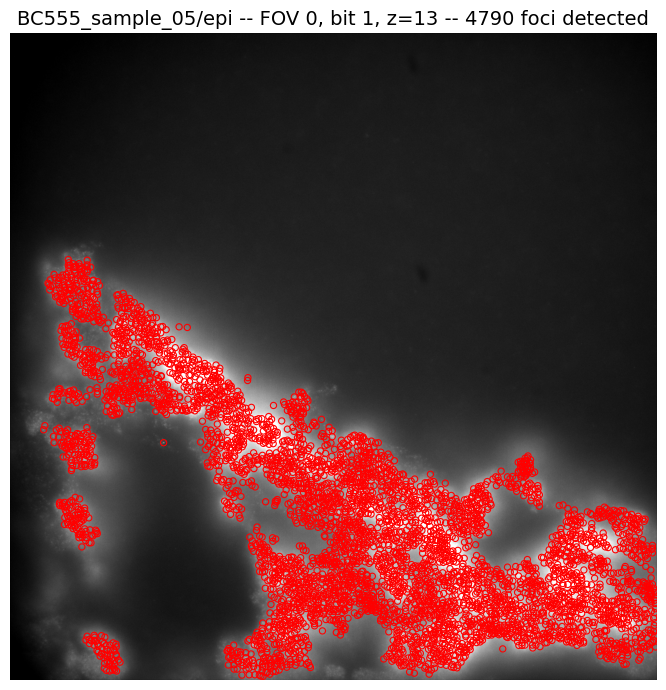

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_foci_density.example_foci_overlay.png


In [5]:
example_fov_id   = sorted(meta_555.fovs)[0]
example_bit      = sorted(bit_lookup_555)[0]
example_round_id, example_frame_idx = bit_lookup_555[example_bit]
example_series   = bits_series_555[example_round_id]
example_path     = example_series.resolve_path(example_fov_id, config_555.image_suffix)

frames = read_image_frames(example_path, [example_frame_idx],
                            frame_width=config_555.frame_width, frame_height=config_555.frame_height)
max_proj, bg_med, candidates = detect_foci_in_crop(frames, CROP_SIZE, FOCI_MIN_DIST_PX, FOCI_THRESH_SIGMA)

vmin, vmax = np.percentile(max_proj, [1.0, 99.0])
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(max_proj, cmap="gray", vmin=vmin, vmax=vmax)
if len(candidates):
    ax.scatter(candidates[:, 1], candidates[:, 0], s=20, facecolors="none", edgecolors="red", linewidths=0.8)
ax.set_title(f"BC555_sample_05/epi -- FOV {example_fov_id}, bit {example_bit}, z={z_used_555} "
             f"-- {len(candidates)} foci detected", fontsize=PLOT_TITLE_FONTSIZE)
ax.axis("off")
fig.tight_layout()
fig_path = figures_dir_555 / f"{NOTEBOOK_NAME}.example_foci_overlay.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 6 — Calculation: per-FOV foci (`BC555_sample_05/epi`)

In [ ]:
foci_df_555 = compute_foci_per_fov(
    config_555, meta_555, bit_lookup_555, bits_series_555,
    cache_dir_555 / "foci_per_fov.csv",
    FOCI_MIN_DIST_PX, FOCI_THRESH_SIGMA, CROP_SIZE,
    "BC555_sample_05/epi", FORCE_RECOMPUTE,
)

## 7 — Calculation: tissue fraction (`BC555_sample_05/epi`)

In [ ]:
tissue_df_555, threshold_555 = compute_tissue_fraction(
    config_555, meta_555, tissue_cache_dir_555, "BC555_sample_05/epi",
    n_background_frames=N_BACKGROUND_FRAMES,
)
tissue_df_555.to_csv(cache_dir_555 / "tissue_fraction_per_fov.csv", index=False)
merged_555 = foci_df_555.merge(tissue_df_555, on="fov_id", how="inner")

## 8 — Heatmaps (`BC555_sample_05/epi`)

In [ ]:
plot_heatmaps(merged_555, meta_555, "BC555_sample_05/epi",
              figures_dir_555 / f"{NOTEBOOK_NAME}.heatmaps.png")

## 9 — Histograms (`BC555_sample_05/epi`)

In [ ]:
plot_histograms(merged_555, "BC555_sample_05/epi",
                 figures_dir_555 / f"{NOTEBOOK_NAME}.histograms.png")

## 10 — Scatter: foci count vs. tissue fraction (`BC555_sample_05/epi`)

In [ ]:
plot_scatter(merged_555, "BC555_sample_05/epi",
             figures_dir_555 / f"{NOTEBOOK_NAME}.foci_vs_tissue_fraction.png")

## 11 — Resolve `BC553_sample_02/epi`

Neither foci detection nor tissue fraction needs MERlin decode/optimize
output -- only raw `bits`/`cells` frames -- so `BC553_sample_02/epi`'s
intact raw `data/` (1,651 FOVs, vs. `BC555_sample_05/epi`'s 476) is enough
even though its decode output was already cleaned up (see
`test_weighted_average_intensity.ipynb` section 0).

In [ ]:
sample_name_553, config_553, meta_553 = resolve_dataset(BC553_DIR)

cache_dir_553 = config_553.analysis_dir / "cache" / NOTEBOOK_NAME
cache_dir_553.mkdir(parents=True, exist_ok=True)
figures_dir_553 = config_553.analysis_dir / "figures"
figures_dir_553.mkdir(parents=True, exist_ok=True)
tissue_cache_dir_553 = config_553.analysis_dir / "cache" / TISSUE_CACHE_NAME

print(f"Sample name: {sample_name_553}")
print(f"FOVs       : {meta_553.n_fovs}")

bit_lookup_553, bits_series_553, z_used_553 = resolve_barcode_bit_lookup(
    config_553, meta_553, N_BARCODE_BITS, Z_PLANE, "BC553_sample_02/epi")

## 12 — Calculation: per-FOV foci (`BC553_sample_02/epi`)

In [ ]:
foci_df_553 = compute_foci_per_fov(
    config_553, meta_553, bit_lookup_553, bits_series_553,
    cache_dir_553 / "foci_per_fov.csv",
    FOCI_MIN_DIST_PX, FOCI_THRESH_SIGMA, CROP_SIZE,
    "BC553_sample_02/epi", FORCE_RECOMPUTE,
)

## 13 — Calculation: tissue fraction (`BC553_sample_02/epi`)

In [ ]:
tissue_df_553, threshold_553 = compute_tissue_fraction(
    config_553, meta_553, tissue_cache_dir_553, "BC553_sample_02/epi",
    n_background_frames=N_BACKGROUND_FRAMES,
)
tissue_df_553.to_csv(cache_dir_553 / "tissue_fraction_per_fov.csv", index=False)
merged_553 = foci_df_553.merge(tissue_df_553, on="fov_id", how="inner")

## 14 — Heatmaps (`BC553_sample_02/epi`)

In [ ]:
plot_heatmaps(merged_553, meta_553, "BC553_sample_02/epi",
              figures_dir_553 / f"{NOTEBOOK_NAME}.heatmaps.png")

## 15 — Histograms (`BC553_sample_02/epi`)

In [ ]:
plot_histograms(merged_553, "BC553_sample_02/epi",
                 figures_dir_553 / f"{NOTEBOOK_NAME}.histograms.png")

## 16 — Scatter: foci count vs. tissue fraction (`BC553_sample_02/epi`)

In [ ]:
plot_scatter(merged_553, "BC553_sample_02/epi",
             figures_dir_553 / f"{NOTEBOOK_NAME}.foci_vs_tissue_fraction.png")